# SAED 衍射斑点分割 — SAM 3（自动阈值）

使用 SAM 3 检测衍射斑点，**自动确定阈值**，无需手动调参。

## 1. 环境准备

In [1]:
import sys, os, numpy as np
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle
import torch

# 中文字体
for _f in matplotlib.font_manager.findSystemFonts():
    if "NotoSansCJK" in _f or "NotoSerifCJK" in _f:
        matplotlib.rcParams["font.family"] = matplotlib.font_manager.FontProperties(fname=_f).get_name()
        break
matplotlib.rcParams["axes.unicode_minus"] = False

SAM3_ROOT = "/media/chenguisen/WD_BLACK1/AISI/autoTEM/sam3"
sys.path.insert(0, SAM3_ROOT)
print(f"Torch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")

Torch: 2.10.0+cu128, CUDA: True


## 2. 构建 SAM 3

In [2]:
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

CHECKPOINT_PATH = os.path.join(SAM3_ROOT, "checkpoints", "sam3.pt")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Building SAM 3...")
model = build_sam3_image_model(
    checkpoint_path=CHECKPOINT_PATH, device=DEVICE,
    eval_mode=True, enable_segmentation=True, enable_inst_interactivity=False,
)
print(f"Parameters: {sum(p.numel() for p in model.parameters())/1e6:.0f}M")

# 关键: threshold=0 获取全部 200 个预测
processor = Sam3Processor(model, resolution=1008, device=DEVICE, confidence_threshold=0.0)
print("Processor ready")

/media/chenguisen/WD_BLACK1/AISI/autoTEM/sam3/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/media/chenguisen/WD_BLACK1/AISI/autoTEM/sam3/.venv/lib/python3.13/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Building SAM 3...
Parameters: 841M
Processor ready


## 3. 加载 SAED 图像

直接加载 PNG 图像，不加载 npy 数据。

In [3]:
SAED_DIR = "/media/chenguisen/WD_BLACK1/AISI/autoTEM/axis-det-tilt/notebooks/saed_pipeline/regression_results/20260512_133140/SrTiO3_011_a2p0_b2p0/all_figures/fig01_observed_saed_iter1.png"
img_pil = Image.open(SAED_DIR).convert("RGB")
# 缩放到合理尺寸（SAM 3 内部用 1008x1008，更大只会浪费显存）
if max(img_pil.size) > 1008:
    img_pil.thumbnail((1008, 1008), Image.LANCZOS)
print(f"Image: {img_pil.size}, mode: {img_pil.mode}")

Image: (980, 1008), mode: RGB


## 4. 推理 + 自动阈值

设置 `confidence_threshold=0` 拿到全部 200 个预测，然后自动分析分数分布确定最佳截断点。

推理中...
总预测: 200, 分数范围: 0.0345 ~ 0.8382
自动阈值: 0.6632 (肘部位置 #15, 跳过前1个)
Top-5 分数: [0.838, 0.801, 0.781, 0.769, 0.769]
自动保留 15 个衍射斑点


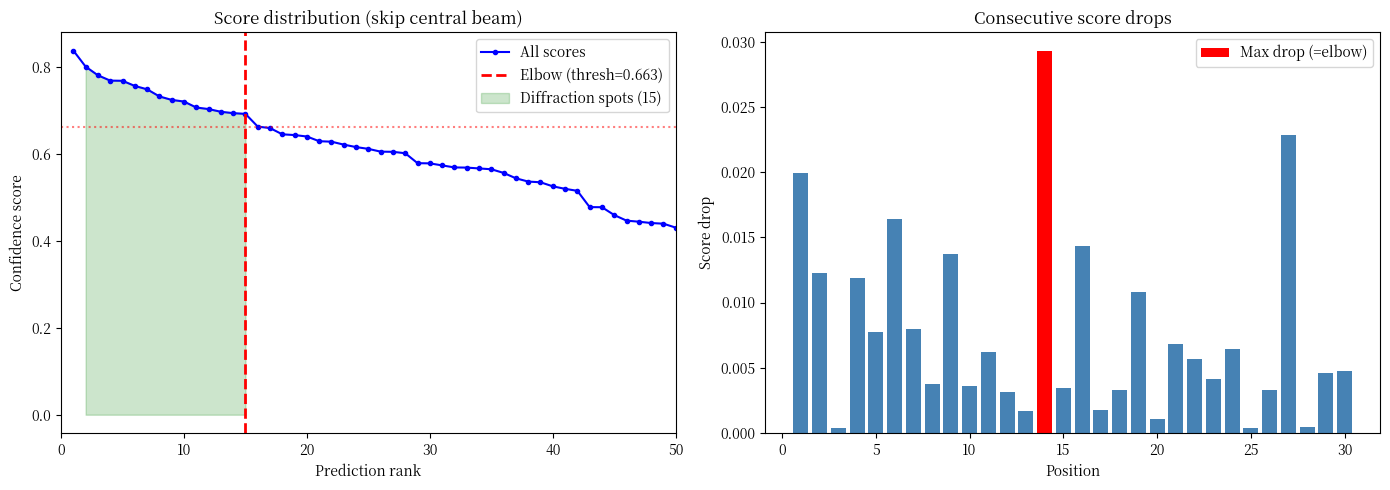

In [4]:
def auto_threshold_filter(scores, masks, boxes, skip_top=1):
    """自动分析分数分布，找到最佳截断点（肘部法）
    skip_top: 跳过前 N 个最高分（通常是透射斑），找衍射斑的阈值
    """
    s = np.sort(scores)[::-1]
    s_rest = s[skip_top:]  # 跳过透射斑
    drops = [s_rest[i] - s_rest[i+1] for i in range(min(30, len(s_rest)-1))]
    elbow = np.argmax(drops) + 1
    thresh = s_rest[elbow]
    print(f"自动阈值: {thresh:.4f} (肘部位置 #{elbow+1}, 跳过前{skip_top}个)")
    print(f"Top-5 分数: {[round(float(x), 3) for x in s[:5]]}")
    keep = scores > thresh
    return masks[keep], boxes[keep], scores[keep], thresh

print("推理中...")
state = processor.set_image(img_pil)
output = processor.set_text_prompt(prompt="a bright spot", state=state)

scores_np = output["scores"].cpu().numpy()
print(f"总预测: {len(scores_np)}, 分数范围: {scores_np.min():.4f} ~ {scores_np.max():.4f}")

# 自动阈值过滤（跳过最高分=透射斑）
masks, boxes, scores, auto_thresh = auto_threshold_filter(
    scores_np, output["masks"], output["boxes"], skip_top=1
)
print(f"自动保留 {len(masks)} 个衍射斑点")

if DEVICE == "cuda":
    torch.cuda.empty_cache()

# 可视化分数分布和肘部位置
import matplotlib.pyplot as plt
_s = np.sort(scores_np)[::-1]
_skip = 1  # 跳过透射斑
_s_rest = _s[_skip:]
_drops = [_s_rest[j] - _s_rest[j+1] for j in range(min(30, len(_s_rest)-1))]
_elbow = np.argmax(_drops) + 1
_thresh = _s_rest[_elbow]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(range(1, len(_s)+1), _s, "b-o", markersize=3, label="All scores")
ax.axvline(x=_elbow+_skip, color="r", linestyle="--", linewidth=2, label=f"Elbow (thresh={_thresh:.3f})")
ax.axhline(y=_thresh, color="r", linestyle=":", alpha=0.5)
ax.fill_between(range(_skip+1, _elbow+_skip+1), 0, _s_rest[:_elbow], alpha=0.2, color="green", label=f"Diffraction spots ({_elbow+1})")
ax.set_xlabel("Prediction rank"); ax.set_ylabel("Confidence score")
ax.set_title("Score distribution (skip central beam)")
ax.legend(); ax.set_xlim(0, 50)

ax = axes[1]
ax.bar(range(1, len(_drops)+1), _drops, color="steelblue")
_drop_idx = _elbow  # already 1-indexed
ax.bar(_drop_idx, _drops[_drop_idx-1], color="red", label="Max drop (=elbow)")
ax.set_xlabel("Position"); ax.set_ylabel("Score drop")
ax.set_title("Consecutive score drops")
ax.legend()
plt.tight_layout(); plt.show()

## 5. 可视化

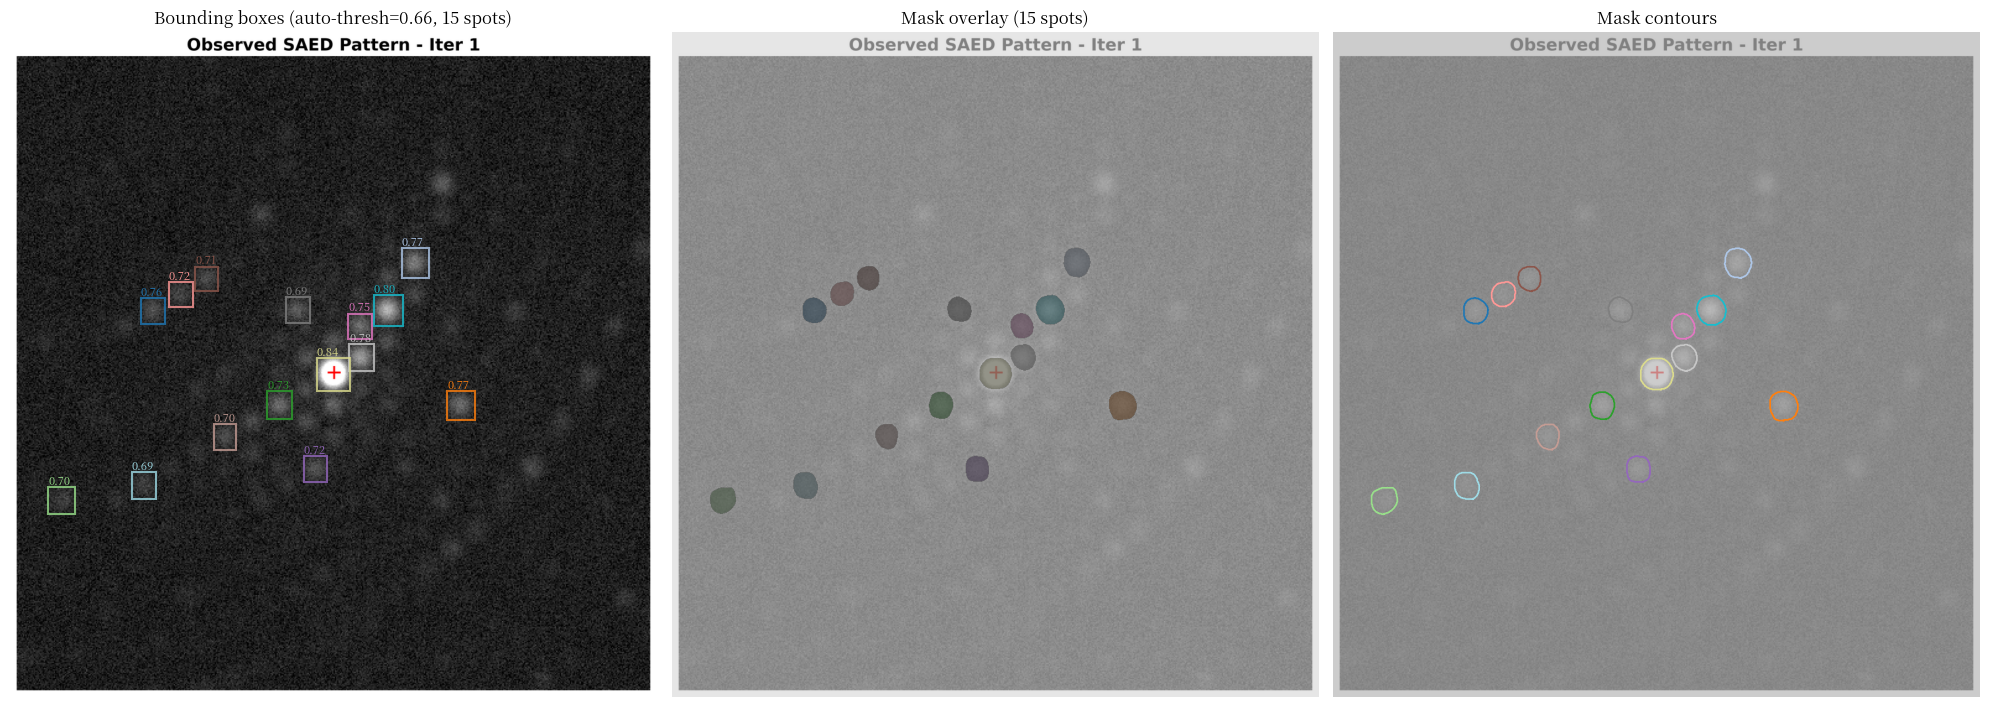

In [5]:
def visualize(masks, boxes, scores, img_pil, auto_thresh):
    img_np = np.array(img_pil.convert("RGB"))
    h, w, _ = img_np.shape
    n = len(masks)
    
    masks_np = masks.cpu().numpy().squeeze() if hasattr(masks, "cpu") else np.array(masks)
    if masks_np.ndim == 4: masks_np = masks_np[:, 0]
    boxes_np = boxes.cpu().numpy() if hasattr(boxes, "cpu") else np.array(boxes)
    scores_np = scores.cpu().numpy() if hasattr(scores, "cpu") else np.array(scores)
    colors = plt.cm.tab20(np.linspace(0, 1, n))

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    
    ax = axes[0]; ax.imshow(img_np)
    for i in range(n):
        x0, y0, x1, y1 = boxes_np[i]
        ax.add_patch(mpatches.Rectangle((x0, y0), x1-x0, y1-y0, linewidth=1.5, edgecolor=colors[i], facecolor="none", alpha=0.8))
        ax.text(x0, y0-4, f"{scores_np[i]:.2f}", fontsize=8, color=colors[i])
    ax.set_title(f"Bounding boxes (auto-thresh={auto_thresh:.2f}, {n} spots)", fontsize=12)
    ax.axis("off")

    ax = axes[1]; ax.imshow((img_np * 0.4 + 128).clip(0, 255).astype(np.uint8))
    overlay = np.zeros((h, w, 4), dtype=np.float32)
    for i in range(n):
        mask = masks_np[i]
        if mask.shape != (h, w):
            from skimage.transform import resize
            mask = resize(mask.astype(float), (h, w), preserve_range=True) > 0.5
        for c in range(3):
            overlay[mask, c] = overlay[mask, c] * 0.7 + colors[i][c] * 0.3
        overlay[mask, 3] = np.maximum(overlay[mask, 3], 0.5)
    overlay[:,:,3] = np.clip(overlay[:,:,3], 0, 1)
    ax.imshow(overlay)
    ax.set_title(f"Mask overlay ({n} spots)", fontsize=12)
    ax.axis("off")

    ax = axes[2]; ax.imshow((img_np * 0.3 + 128).clip(0, 255).astype(np.uint8))
    from skimage.measure import find_contours
    for i in range(n):
        mask = masks_np[i]
        if mask.shape != (h, w):
            from skimage.transform import resize
            mask = resize(mask.astype(float), (h, w), preserve_range=True) > 0.5
        for c in find_contours(mask.astype(float), 0.5):
            ax.plot(c[:, 1], c[:, 0], linewidth=1.2, color=colors[i])
    ax.set_title("Mask contours", fontsize=12)
    ax.axis("off")
    plt.tight_layout(); plt.show()
    return masks_np, boxes_np, scores_np

# 调用 visualize
masks_np, boxes_np, scores_np = visualize(masks, boxes, scores, img_pil, auto_thresh)

## 6. 提取斑点参数

In [6]:
def extract_spots(masks_np, boxes_np, scores_np, image_np):
    h, w = image_np.shape[:2]
    gray = image_np.mean(axis=2) if image_np.ndim == 3 else image_np
    spots = []
    # 确保 masks_np 是 3D (N, H, W)
    if masks_np.ndim == 2:
        masks_np = masks_np[np.newaxis, :, :]
    elif masks_np.ndim == 4:
        masks_np = masks_np[:, 0]
    # 用 enumerate 同时迭代 mask 和 score
    for idx, mask in enumerate(masks_np):
        score = float(scores_np[idx]) if idx < len(scores_np) else 0.0
        if mask.shape != (h, w):
            from skimage.transform import resize
            mask = resize(mask.astype(float), (h, w), preserve_range=True) > 0.5
        if np.sum(mask) == 0:
            continue
        ys, xs = np.where(mask)
        spots.append({"index": idx, "cx": float(np.mean(xs)), "cy": float(np.mean(ys)),
                      "radius": float(np.sqrt(np.sum(mask)/np.pi)),
                      "intensity": float(np.sum(gray[mask])),
                      "peak": float(np.max(gray[mask])),
                      "confidence": score})
    return spots

# 提取斑点参数
spots = extract_spots(masks_np, boxes_np, scores_np, np.array(img_pil))
cx, cy = np.array(img_pil).shape[1]/2, np.array(img_pil).shape[0]/2
for s in spots:
    s["dist"] = np.sqrt((s["cx"]-cx)**2 + (s["cy"]-cy)**2)
spots.sort(key=lambda s: s["dist"])

print(f"{chr(35):>3} | Cx     | Cy     | Rad  | Intensity | Peak  | Conf")
print("-"*55)
for i, s in enumerate(spots):
    print(f"{i+1:>3} | {s["cx"]:>7.1f} | {s["cy"]:>7.1f} | {s["radius"]:>5.1f} | {s["intensity"]:>9.0f} | {s["peak"]:>6.1f} | {s["confidence"]:>6.3f}")

  # | Cx     | Cy     | Rad  | Intensity | Peak  | Conf
-------------------------------------------------------
  1 |   489.6 |   518.0 |  24.6 |    394862 |  255.0 |  0.838
  2 |   531.9 |   493.0 |  19.3 |    125711 |  171.0 |  0.781
  3 |   529.5 |   446.0 |  18.3 |     83620 |  132.0 |  0.749
  4 |   434.8 |   421.1 |  18.7 |     74130 |  108.0 |  0.694
  5 |   406.9 |   566.0 |  19.8 |     92272 |  126.0 |  0.733
  6 |   572.5 |   421.4 |  22.2 |    171922 |  194.0 |  0.801
  7 |   461.9 |   662.4 |  19.3 |     71536 |  101.0 |  0.725
  8 |   612.7 |   349.7 |  21.4 |    116838 |  145.0 |  0.769
  9 |   325.1 |   612.8 |  18.3 |     60459 |  101.0 |  0.704
 10 |   682.0 |   566.6 |  22.0 |    107356 |  128.0 |  0.769
 11 |   297.0 |   373.4 |  18.0 |     58516 |  102.0 |  0.707
 12 |   257.5 |   397.1 |  18.4 |     57648 |   97.0 |  0.721
 13 |   214.9 |   422.5 |  19.0 |     67266 |  108.0 |  0.757
 14 |   201.8 |   687.4 |  19.8 |     60312 |   93.0 |  0.692
 15 |    76.8 |   70

## 7. 标注图

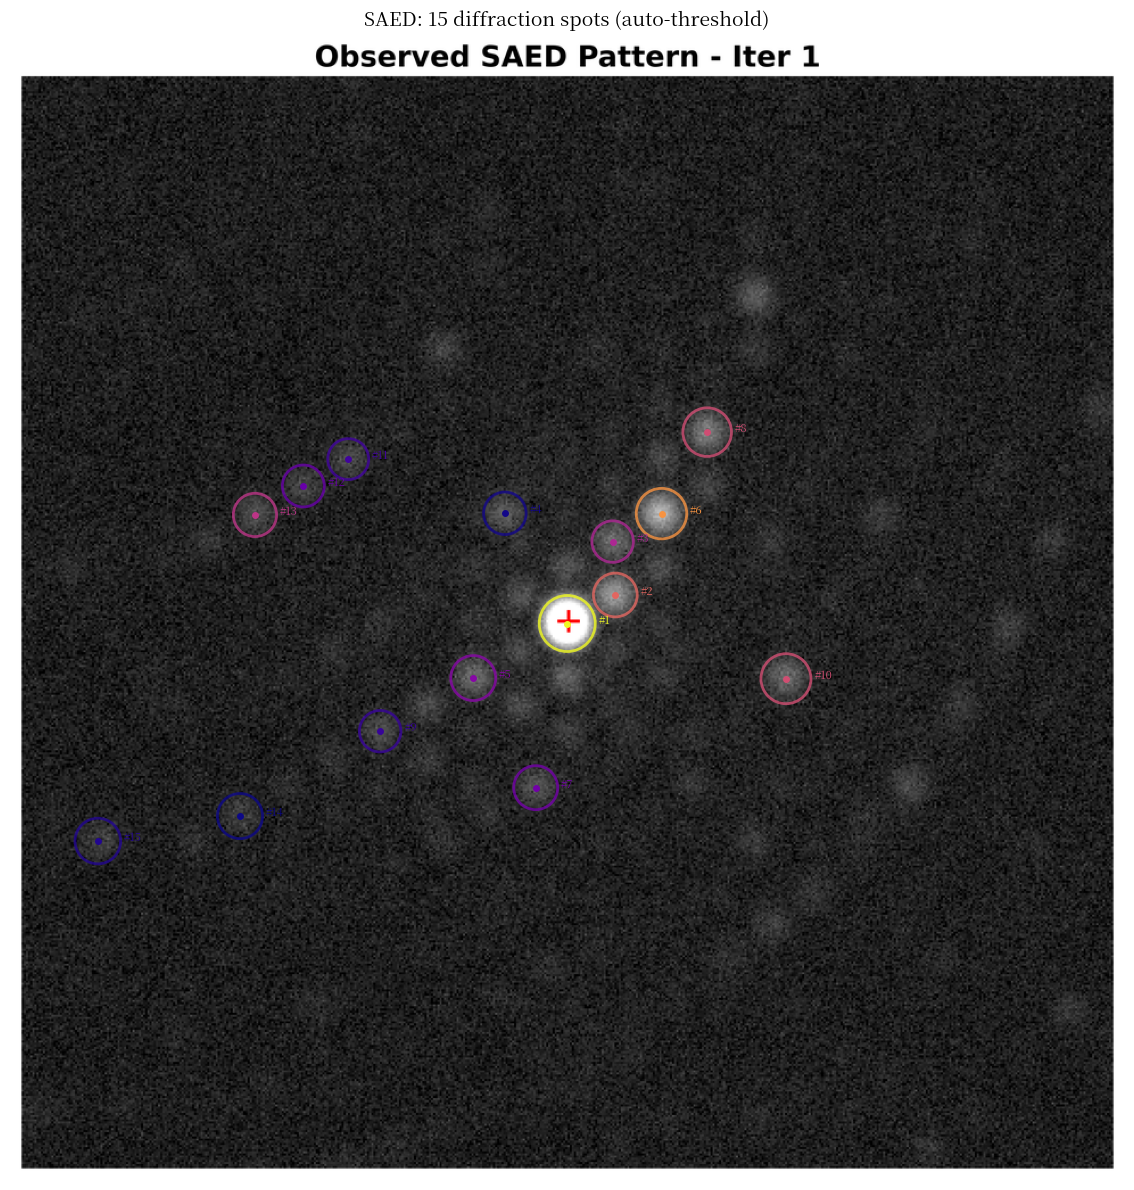

In [7]:
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(np.array(img_pil))
vmin, vmax = min(s["confidence"] for s in spots), max(s["confidence"] for s in spots)
for i, s in enumerate(spots):
    c = plt.cm.plasma((s["confidence"]-vmin)/(vmax-vmin+1e-8))
    ax.add_patch(Circle((s["cx"], s["cy"]), s["radius"], fill=False, color=c, linewidth=2, alpha=0.8))
    ax.plot(s["cx"], s["cy"], 'o', color=c, markersize=4)
    ax.text(s["cx"]+s["radius"]+3, s["cy"], f"#{i+1}", fontsize=8, color=c)
ax.set_title(f"SAED: {len(spots)} diffraction spots (auto-threshold)", fontsize=14)
ax.axis("off")
plt.tight_layout(); plt.show()

## 8. 保存结果

In [8]:
import json, csv
# 保存到 SAED_DIR（支持目录路径或文件路径）
out_dir = SAED_DIR if os.path.isdir(SAED_DIR) else os.path.dirname(SAED_DIR)
os.makedirs(out_dir, exist_ok=True)
with open(os.path.join(out_dir, "sam3_spots.json"), "w") as f:
    json.dump(spots, f, indent=2)
with open(os.path.join(out_dir, "sam3_spots.csv"), "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["index","cx","cy","radius","intensity","peak","confidence","dist"])
    w.writeheader(); w.writerows(spots)
print(f"Saved to {out_dir}")

Saved to /media/chenguisen/WD_BLACK1/AISI/autoTEM/axis-det-tilt/notebooks/saed_pipeline/regression_results/20260512_133140/SrTiO3_011_a2p0_b2p0/all_figures


## 9. 总结

完全自动化的 SAM 3 衍射斑点分割：
- `confidence_threshold=0` 获取全部 200 个预测
- 肘部法自动确定最佳截断点
- 无需手动调参